In [ ]:
import pandas as pd
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn import metrics
import plotly.express as px
import plotly.graph_objects as go
import statsmodels.api as sm
import seaborn as sns
from statsmodels.stats.weightstats import ztest,ttest_ind
import scipy.stats as st

In [ ]:
df2 = pd.read_csv("Datasets/dataset2_cleaned_V3.csv")

df2.info()
df2.describe()
df2.head()

# Now we are going to see the number of rows and columns in the dataset
print(f"Dataset 2 dimensions: ") 
print(f"Number of rows: {df2.shape[0]}") 
print(f"Number of columns: {df2.shape[1]}")


# Splitting the DataFrame based on the column 'B'
df2_0 = df2[(df2['month'] == 0)]
df2_1 = df2[(df2['month'] == 1)]
df2_2 = df2[(df2['month'] == 2)]
df2_3 = df2[(df2['month'] == 3)]
df2_4 = df2[(df2['month'] == 4)]
df2_5 = df2[(df2['month'] == 5)]
df2_6 = df2[(df2['month'] == 6)]

lengths = {
    '0': len(df2_0),
    '1': len(df2_1),
    '2': len(df2_2),
    '3': len(df2_3),
    '4': len(df2_4),
    '5': len(df2_5),
    '6': len(df2_6)

}

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1897 entries, 0 to 1896
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   time                1897 non-null   object 
 1   month               1897 non-null   int64  
 2   hours_after_sunset  1897 non-null   float64
 3   bat_landing_number  1897 non-null   int64  
 4   food_availability   1897 non-null   float64
 5   rat_minutes         1897 non-null   float64
 6   rat_arrival_number  1897 non-null   int64  
 7   season_code         1885 non-null   float64
dtypes: float64(4), int64(3), object(1)
memory usage: 118.7+ KB
Dataset 2 dimensions: 
Number of rows: 1897
Number of columns: 8


In [ ]:
def p_value_grapher(dataframes,dataset_split_parameter,test_column):
    
                   
                   #, 'food_availability','hours_after_sunset']
    # Loop through each DataFrame
    # Loop through each DataFrame
    # Initialize an empty list to store p-values
    p_values = []
    
    # Loop through each DataFrame
    for df in dataframes:
        for x in dataset_split_parameter:
            for y in test_column:
                # Converts the x column to integers
                df=df.copy()
                df[x] = df[x].astype(int)
    
                # Creates two dataframes as per the two sections
                df_above_zero = df[df[x] > 0]
                df_zero = df[df[x] == 0]
    
                # Perform Z-test if both groups have samples
                if len(df_above_zero) >= 30 and len(df_zero) >= 30:
                    z_stats, p_val = ztest(df_above_zero[y], df_zero[y], alternative='two-sided')
    
                    # Append the p-value to the list
                    p_values.append(p_val)
    
                    # Determine whether to accept or reject the null hypothesis
                    conclusion = "We reject the null hypothesis." if p_val < 0.05 else "We accept the null hypothesis."
                else:
                    t_stats, p_val = st.ttest_ind(a=df_above_zero[y], b=df_zero[y],equal_var=False, alternative='two-sided')
    
                    # Append the p-value to the list
                    p_values.append(p_val)
    
                    # Determine whether to accept or reject the null hypothesis
                    conclusion = "We reject the null hypothesis." if p_val < 0.05 else "We accept the null hypothesis."
                    
    
                    # Print Z-test statistic, p-value, and conclusion
                    # print(f"Z-statistic: {z_stats:.2f}, p-value: {p_val:.10f}, Conclusion: {conclusion}")
  
                
    
    # Optionally, print the list of p-values after the loop
    # print("\nList of p-values:", p_values)
                    
    # Assuming p_values contains at least 12 values
    # Example p_values for demonstration
    # p_values = [0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09, 0.10, 0.11, 0.12]
    
    # plt.figure(figsize=(10, 6))
    
    # # Plot the first 6 p-values in red
    # plt.scatter(range(6), p_values[:6], color='red', marker='o', label='rat_arrival_number')
    
    # # Plot the last 6 p-values in blue
    # plt.scatter(range(6, 12), p_values[6:12], color='blue', marker='o', label='rat_minutes')
    
    # # Add a horizontal line for the significance level
    # plt.axhline(y=0.05, color='red', linestyle='--', label='Significance Level (0.05)')
    
    # # Title and labels
    # plt.title('Scatter Plot of p-values from Z-tests')
    # plt.xlabel('Test Index')
    # plt.ylabel('p-value')
    # plt.xticks(range(12))  # Set x-ticks to match the number of p-values
    # plt.ylim(0, 1)  # Set y-axis limits
    # plt.legend()
    # plt.grid()
    # plt.show()
    
    # Create a figure with two subplots
    rat_arrival_number_p_value_list=[]
    rat_minutes_p_value_list=[]
    for i in [0,2,4,6,8,10]:
        rat_arrival_number_p_value_list.append(p_values[i])
    for s in [1,3,5,6,9,11]:
        rat_minutes_p_value_list.append(p_values[s])    
        
    # plt.figure(figsize=(10, 12))
    
    # # First subplot for the first 6 p-values
    # plt.subplot(2, 1, 1)  # 2 rows, 1 column, 1st subplot
    # plt.scatter(x=range(6), y=rat_arrival_number_p_value_list, color='red', marker='o', label='rat_arrival_number')
    # plt.axhline(y=0.05, color='red', linestyle='--', label='Significance Level (0.05)')
    # plt.title('Scatter Plot of First 6 p-values from Z-tests for Bat_landing_Number')
    # plt.xlabel('Test Index')
    # plt.ylabel('p-value')
    # plt.xticks(range(6))  # Set x-ticks to match the number of p-values
    # plt.ylim(0, 1)  # Set y-axis limits
    # plt.legend()
    # plt.grid()
    
    # # Second subplot for the last 6 p-values
    # plt.subplot(2, 1, 2)  # 2 rows, 1 column, 2nd subplot
    # plt.scatter(x=range(6), y=rat_minutes_p_value_list, color='blue', marker='o', label='rat_minutes')
    # plt.axhline(y=0.05, color='red', linestyle='--', label='Significance Level (0.05)')
    # plt.title('Scatter Plot of Last 6 p-values from Z-tests for Bat_landing_Number')
    # plt.xlabel('Test Index')
    # plt.ylabel('p-value')
    # plt.xticks(range(6))  # Set x-ticks to match the number of p-values
    # plt.ylim(0, 1)  # Set y-axis limits
    # plt.legend()
    # plt.grid()
    
    # # Adjust layout to prevent overlap
    # plt.tight_layout()
    # plt.show()
    return rat_arrival_number_p_value_list, rat_minutes_p_value_list

In [ ]:
a,b = p_value_grapher([df2_0, df2_1, df2_2, df2_3, df2_4, df2_5],['rat_arrival_number', 'rat_minutes'],['bat_landing_number'])
c,d = p_value_grapher([df2_0, df2_1, df2_2, df2_3, df2_4, df2_5],['rat_arrival_number', 'rat_minutes'],['food_availability'])
e,f = p_value_grapher([df2_0, df2_1, df2_2, df2_3, df2_4, df2_5],['rat_arrival_number', 'rat_minutes'],['hours_after_sunset'])

In [ ]:
# Create a line of best fit and plot
def plot_with_best_fit(df_a, df_b):
    # Create arrays for x values (0 through 5 for 6 data points)
    x_values = np.arange(len(df_a))

    # Get the p-values
    y_a = df_a
    y_b = df_b

    # Calculate line of best fit
    coeffs_a = np.polyfit(x_values, y_a, 1)
    best_fit_line_a = np.polyval(coeffs_a, x_values)

    coeffs_b = np.polyfit(x_values, y_b, 1)
    best_fit_line_b = np.polyval(coeffs_b, x_values)

    # Plot
    plt.figure(figsize=(12, 6))

    # Plot for rat_arrival_number
    plt.subplot(1, 2, 1)  # 1 row, 2 columns, first subplot
    plt.scatter(x_values, y_a, color='red', label='Rat Arrival Number p-values', marker='o')
    plt.plot(x_values, best_fit_line_a, color='blue', linestyle='--', label='Line of Best Fit')
    plt.axhline(y=0.05, color='green', linestyle='--', label='Significance Level (0.05)')
    plt.title('Rat Arrival Number P-values with Best Fit')
    plt.xlabel('Test Index')
    plt.ylabel('p-value')
    plt.ylim(0, 1)
    plt.xticks(x_values)
    plt.legend()
    plt.grid()

    # Plot for rat_minutes
    plt.subplot(1, 2, 2)  # 1 row, 2 columns, second subplot
    plt.scatter(x_values, y_b, color='blue', label='Rat Minutes p-values', marker='o')
    plt.plot(x_values, best_fit_line_b, color='red', linestyle='--', label='Line of Best Fit')
    plt.axhline(y=0.05, color='green', linestyle='--', label='Significance Level (0.05)')
    plt.title('Rat Minutes P-values with Best Fit')
    plt.xlabel('Test Index')
    plt.ylabel('p-value')
    plt.ylim(0, 1)
    plt.xticks(x_values)
    plt.legend()
    plt.grid()

    plt.tight_layout()
    plt.show()

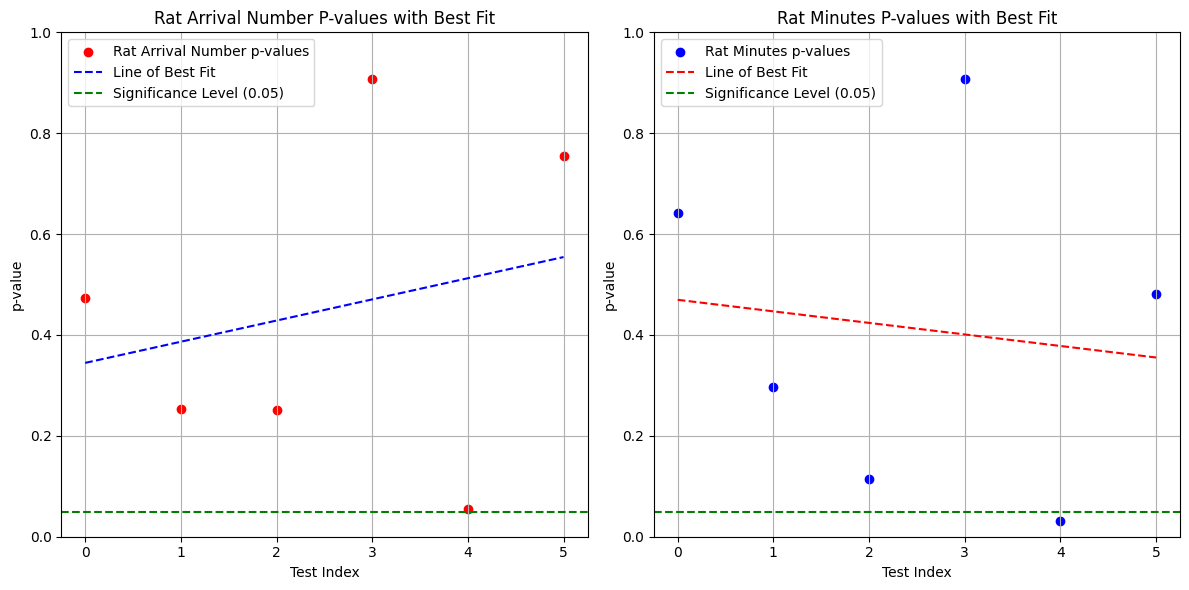

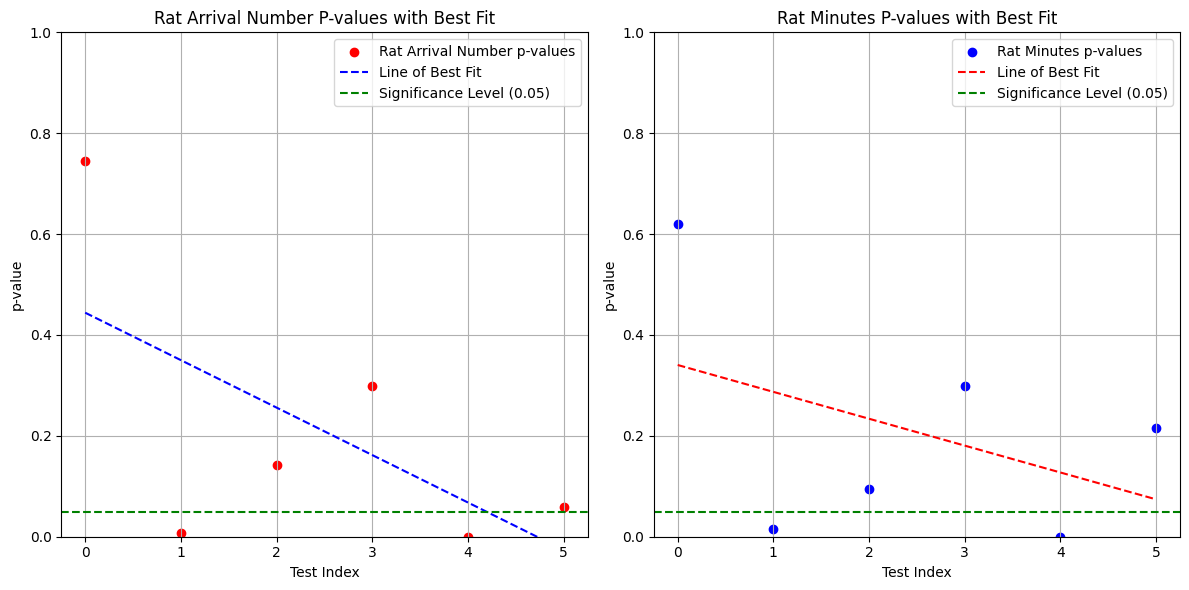

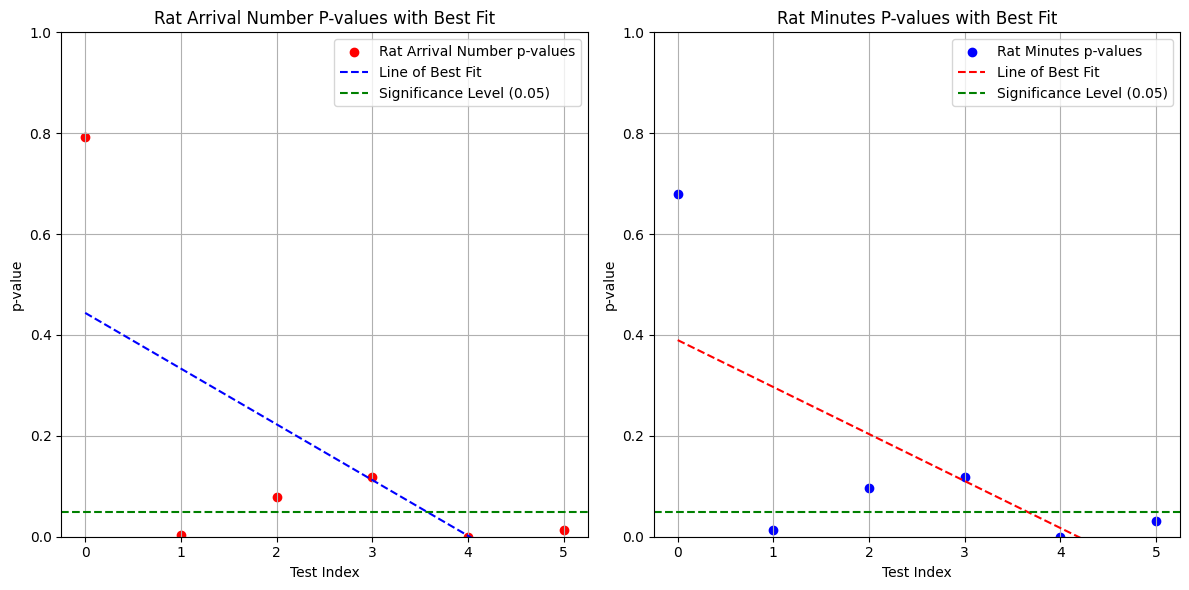

In [ ]:
# Call the plotting function
plot_with_best_fit(a, b)
plot_with_best_fit(c, d)
plot_with_best_fit(e, f)

In [ ]:
p1 = pd.DataFrame(p_value_grapher([df2_0, df2_1, df2_2, df2_3, df2_4, df2_5],['rat_arrival_number', 'rat_minutes'],['bat_landing_number']))

In [ ]:
p2 = pd.DataFrame(p_value_grapher([df2_0, df2_1, df2_2, df2_3, df2_4, df2_5],['rat_arrival_number', 'rat_minutes'],['food_availability']))
p3 = pd.DataFrame(p_value_grapher([df2_0, df2_1, df2_2, df2_3, df2_4, df2_5],['rat_arrival_number', 'rat_minutes'],['hours_after_sunset']))

In [ ]:
p_vert = pd.concat([p1, p2, p3], axis=1, join='outer', ignore_index=True)